In [5]:
# python3 -m pip install --upgrade pip setuptools
# pip install -e .
# python -m ipykernel install --user --name=nome-do-seu-venv
# %load_ext autoreload
# %autoreload 2


# Análise de Dados de Transações Fraudulentas

## Análise Exploratória de Dados (EDA) e Preparação de Dados

### Metodologia: Estrutura CRISP-DM

Este projeto é estruturado com base na estrutura Processo Padrão Inter-Indústrias para Mineração de Dados (CRISP-DM) para garantir uma abordagem abrangente e alinhada ao negócio para a deteção de fraudes.

Este bloco de notas em particular abrange as três primeiras fases da metodologia:

1. Definir o problema de negócio.
2. Compreensão dos dados
3. Preparação de dados
4. Explorar os dados (análise exploratória de dados).
5. Limpeza e pré-processamento de dados.
6. Treino, comparação, seleção e afinação do modelo.
7. Teste e avaliação final do modelo de produção.
8. Concluir e interpretar os resultados do modelo.
9. Implementar.

# **1. DEFINIR O PROBLEMA DE NEGÓCIO**

A Home Credit busca ampliar a inclusão financeira da população desbancarizada, proporcionando uma experiência de crédito positiva e segura. Para garantir que esse público, frequentemente desatendido, tenha uma experiência positiva com o empréstimo, a Home Credit utiliza uma variedade de dados alternativos — incluindo informações de telecomunicações e dados transacionais — para prever a capacidade de pagamento de seus clientes.


A métrica que será utilizada para medirmos a eficiência do modelo será a curva ROC.

## **1.1 IMPORTANDO BIBLIOTECAS**

In [ ]:
from pathlib import Path
from projeto import visualizer
from projeto import utils 

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt


# **2. COMPREENSÃO DOS DADOS** 

- O dataset foi coletado em: https://www.kaggle.com/competitions/home-credit-default-risk/data

- O conjunto de dados abrange múltiplos ficheiros relacionais estruturados para prever o risco de incumprimento de crédito (default), contendo dados demográficos e estáticos de pedidos de empréstimo, histórico de créditos anteriores em outras instituições (Credit Bureau), histórico de pagamentos, além de dados transacionais e de telecomunicações utilizados para avaliar a capacidade de pagamento de populações subatendidas.

Ana Lina Morelia, inversion, KirillOdintsov, and Martin Kotek. Home Credit Default Risk. https://kaggle.com/competitions/home-credit-default-risk, 2018. Kaggle.

## **2.1 COLETA E INTEGRAÇÃO INICIAL DE DADOS**

In [11]:
# Executa a função principal de carga e junção
df_train, df_test = utils.load_and_merge_home_credit_data()

Carregando application_train e application_test...

Processando base de TREINO:
Processando bureau e bureau_balance...
Processando previous_application...


ValueError: The column label 'SK_ID_CURR' is not unique.

# **3. PREPARAÇÃO DE DADOS**

In [9]:
def process_categorical_application(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Lista de colunas object fornecida
    cat_cols = [
        'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 
        'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 
        'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 
        'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 
        'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'
    ]
    
    # Filtra apenas as que existem no DataFrame
    cat_cols = [col for col in cat_cols if col in df_train.columns]
    
    # Converte para o tipo 'category' do Pandas (ideal para o LightGBM processar nativamente)
    for col in cat_cols:
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')
        
    return df_train, df_test

In [ ]:
(df_train.isna().sum() / len(df_train) * 100).sort_values(ascending=False)

AMT_ANNUITY_min             73.981744
AMT_ANNUITY_max             73.981744
AMT_ANNUITY_mean            73.981744
MONTHS_BALANCE_mean_mean    70.007252
MONTHS_BALANCE_sum_mean     70.007252
                              ...    
FLAG_DOCUMENT_7              0.000000
FLAG_DOCUMENT_8              0.000000
FLAG_DOCUMENT_9              0.000000
FLAG_DOCUMENT_10             0.000000
FLAG_DOCUMENT_11             0.000000
Length: 202, dtype: float64

In [10]:
df_train, df_test = process_categorical_application(df_train, df_test)

# **4. MODELAGEM**

In [8]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import numpy as np

def train_lightgbm_model(df_train: pd.DataFrame, df_test: pd.DataFrame):
    """
    Realiza a etapa 4 (Modelagem) utilizando StratifiedKFold e LightGBM.
    """

    output_dir = Path('/data/PROJETOS/GIT/HONE-CREDIT/data/bronze')

    print("Iniciando a etapa de modelagem...")
    
    # 1. Separar X (features) e y (target)
    drop_cols = ['SK_ID_CURR', 'TARGET']
    features = [col for col in df_train.columns if col not in drop_cols]
    
    X = df_train[features]
    y = df_train['TARGET']
    X_test = df_test[features]
    
    # 2. Configurar o StratifiedKFold
    n_splits = 5
    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    # Arrays para guardar as predições e pontuações
    oof_preds = np.zeros(len(df_train))
    sub_preds = np.zeros(len(df_test))
    feature_importance_df = pd.DataFrame()
    
    # 3. Loop de treinamento por Folds
    for fold, (train_idx, val_idx) in enumerate(folds.split(X, y)):
        print(f"\n--- Treinando Fold {fold + 1} de {n_splits} ---")
        
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        # Instancia o modelo LightGBM com hiperparâmetros básicos para baseline
        model = lgb.LGBMClassifier(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=34,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        
        # Treinamento utilizando early stopping nativo
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_va, y_va)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        
        # Predição na base de validação (OOF)
        oof_preds[val_idx] = model.predict_proba(X_va)[:, 1]
        
        # Predição na base de teste oficial
        sub_preds += model.predict_proba(X_test)[:, 1] / n_splits
        
        # Importância das features
        fold_importance_df = pd.DataFrame()
        fold_importance_df["feature"] = features
        fold_importance_df["importance"] = model.feature_importances_
        feature_importance_df = pd.concat([feature_importance_df, fold_importance_df], axis=0)
        
        print(f"Score ROC-AUC do Fold {fold + 1}: {roc_auc_score(y_va, oof_preds[val_idx]):.4f}")

    # Score geral OOF (Out-Of-Fold)
    overall_auc = roc_auc_score(y, oof_preds)
    print(f"\n============================")
    print(f"ROC-AUC Geral OOF: {overall_auc:.4f}")
    print(f"============================")
    
    # 4. Criação do arquivo de submissão
    submission = pd.DataFrame({
        'SK_ID_CURR': df_test['SK_ID_CURR'],
        'TARGET': sub_preds
    })
    
    output_sub_path = output_dir / "submission_lgb.csv"
    submission.to_csv(output_sub_path, index=False)
    print(f"Arquivo de submissão salvo em: {output_sub_path}")
    
    return submission, feature_importance_df

In [4]:
df_train = pd.read_csv('/data/PROJETOS/GIT/HONE-CREDIT/data/bronze/train_merged.csv')
df_test = pd.read_csv('/data/PROJETOS/GIT/HONE-CREDIT/data/bronze/train_merged.csv')

df_train.shape

(307511, 202)

In [11]:
sub, feature_imp = train_lightgbm_model(df_train, df_test)

Iniciando a etapa de modelagem...

--- Treinando Fold 1 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.401342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26484
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 196
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Score ROC-AUC do Fold 1: 0.7618

--- Treinando Fold 2 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.293812 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26549
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 195
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 2: 0.7715

--- Treinando Fold 3 de 5 ---


...

[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.578747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26467
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 196
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 3: 0.7641

--- Treinando Fold 4 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.196565 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26499
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 196
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 4: 0.7707

--- Treinando Fold 5 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.199851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26451
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 196
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 5: 0.7624

ROC-AUC Geral OOF: 0.7660
Arquivo de submissão salvo em: /data/PROJETOS/GIT/HONE-CREDIT/data/bronze/submission_lgb.csv


<Axes: xlabel='feature', ylabel='importance'>

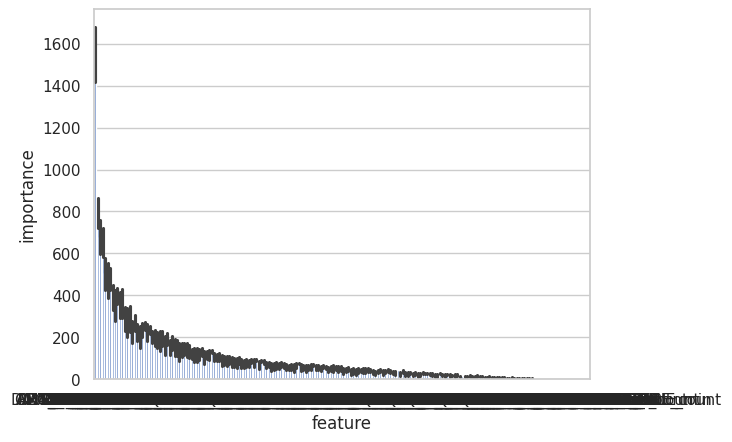

In [12]:
f = feature_imp.sort_values('importance', ascending=False)

sns.barplot(
    f, x='feature', y='importance'
)

# **5. AVALIAÇÃO**

In [13]:
# 1. Agrega a importância das features (certificando o nome correto da variável)
feature_imp_agg = feature_imp.groupby('feature')['importance'].sum().reset_index()

# 2. Seleciona apenas as features úteis (maior que 0)
features_uteis = feature_imp_agg[feature_imp_agg['importance'] > 0]['feature'].tolist()

# 3. Define as colunas finais para Treino e Teste
cols_treino = features_uteis + ['SK_ID_CURR', 'TARGET']
cols_teste = features_uteis + ['SK_ID_CURR']

# 4. Aplica o filtro garantindo que só pegamos colunas que realmente existem no DataFrame
df_train_filtrado = df_train[[col for col in cols_treino if col in df_train.columns]]
df_test_filtrado = df_test[[col for col in cols_teste if col in df_test.columns]]

print(f"Colunas originais de treino: {df_train.shape[1]}")
print(f"Colunas filtradas de treino: {df_train_filtrado.shape[1]} (Incluindo Target e ID)")

Colunas originais de treino: 202
Colunas filtradas de treino: 188 (Incluindo Target e ID)


In [14]:
sub, feature_imp = train_lightgbm_model(df_train_filtrado, df_test)

Iniciando a etapa de modelagem...

--- Treinando Fold 1 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.192226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26283
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Score ROC-AUC do Fold 1: 0.7628

--- Treinando Fold 2 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.249427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26348
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 2: 0.7711

--- Treinando Fold 3 de 5 ---


...

[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.443477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26267
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 3: 0.7641

--- Treinando Fold 4 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26297
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 4: 0.7694

--- Treinando Fold 5 de 5 ---


/data/PROJETOS/GIT/HONE-CREDIT/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.272972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26256
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 186
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Score ROC-AUC do Fold 5: 0.7636

ROC-AUC Geral OOF: 0.7662
Arquivo de submissão salvo em: /data/PROJETOS/GIT/HONE-CREDIT/data/bronze/submission_lgb.csv


<Axes: xlabel='feature', ylabel='importance'>

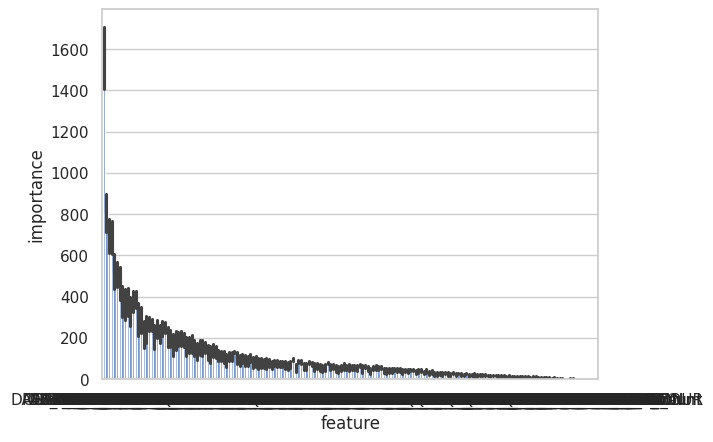

In [15]:
f = feature_imp.sort_values('importance', ascending=False)

sns.barplot(
    f, x='feature', y='importance'
)

In [17]:
df_train['TARGET']

0         1
1         0
2         0
3         0
4         0
         ..
307506    0
307507    0
307508    0
307509    1
307510    0
Name: TARGET, Length: 307511, dtype: int64